# nb04 — Results & Model Comparison
Loads all 4 models' predictions and compares them side by side.

**Run after:** all 4 models have been trained and their predictions saved.

In [2]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import csv

ROOT = os.path.abspath('..')
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, 'evaluation'))
sys.path.insert(0, os.path.join(ROOT, 'models'))
sys.path.insert(0, os.path.join(ROOT, 'features'))

from metrics import evaluate, classification_report, plot_confusion_matrix

CLASS_NAMES   = sorted(['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'])
FEATURES_DIR  = os.path.join(ROOT, 'features')
PROCESSED_DIR = os.path.join(ROOT, 'data', 'processed')
LOGS_DIR      = os.path.join(ROOT, 'logs')
COLORS        = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628']

## 1. Generate predictions from all 4 models

In [3]:
# ---- Load test ground truth ----
test_data = np.load(os.path.join(PROCESSED_DIR, 'test.npz'), allow_pickle=True)
X_test_img = test_data['images'].astype(np.float32)   # (900, H, W, 3)
y_test     = test_data['labels'].astype(np.int32)

# ---- Load MRMR features for KNN and Softmax ----
feat_test  = np.load(os.path.join(FEATURES_DIR, 'test_mrmr.npz'))
X_feat     = feat_test['X'].astype(np.float32)

feat_train = np.load(os.path.join(FEATURES_DIR, 'train_mrmr.npz'))
X_feat_tr  = feat_train['X'].astype(np.float32)
y_train    = feat_train['y'].astype(np.int32)

# Normalize features (same as during training)
mean = X_feat_tr.mean(axis=0)
std  = X_feat_tr.std(axis=0) + 1e-8
X_feat_norm = (X_feat - mean) / std

print(f'Test images: {X_test_img.shape}')
print(f'Test features (MRMR): {X_feat.shape}')
print(f'Test labels: {y_test.shape}')

Test images: (900, 96, 96, 3)
Test features (MRMR): (900, 200)
Test labels: (900,)


In [4]:
# ---- KNN predictions ----
from collections import Counter

class KNN:
    def __init__(self, k=9):
        self.k = k
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def predict(self, X):
        preds = []
        for x in X:
            dists = np.sqrt(((self.X_train - x)**2).sum(axis=1))
            idx   = np.argsort(dists)[:self.k]
            preds.append(Counter(self.y_train[idx]).most_common(1)[0][0])
        return np.array(preds)

print('Running KNN predictions (may take a minute)...')
knn = KNN(k=9)
knn.fit((X_feat_tr - mean) / std, y_train)
y_pred_knn = knn.predict(X_feat_norm)
print(f'KNN accuracy: {(y_pred_knn == y_test).mean():.4f}')

Running KNN predictions (may take a minute)...
KNN accuracy: 0.6300


In [5]:
# ---- Softmax predictions ----
# Find latest softmax checkpoint
import glob
ckpts = sorted(glob.glob(os.path.join(LOGS_DIR, 'softmax_adam_*_best.npz')))
assert len(ckpts) > 0, 'No softmax checkpoint found in logs/'
ckpt = ckpts[-1]
print(f'Loading softmax checkpoint: {os.path.basename(ckpt)}')

from softmax import SoftmaxClassifier
softmax_model = SoftmaxClassifier(n_features=X_feat_norm.shape[1], n_classes=6)
softmax_model.load(ckpt)

# Need to normalize with softmax's own train stats
feat_train_full = np.load(os.path.join(FEATURES_DIR, 'train_mrmr.npz'))
sm_mean = feat_train_full['X'].astype(np.float32).mean(axis=0)
sm_std  = feat_train_full['X'].astype(np.float32).std(axis=0) + 1e-8
X_feat_sm = (feat_test['X'].astype(np.float32) - sm_mean) / sm_std

y_pred_softmax = softmax_model.predict(X_feat_sm)
print(f'Softmax accuracy: {(y_pred_softmax == y_test).mean():.4f}')

Loading softmax checkpoint: softmax_adam_20260510_161226_best.npz
Softmax accuracy: 0.7378


In [6]:
# ---- CNN from scratch predictions ----
# NOTE: CNN was trained on 96x96 images
# If your CNN used a different size, adjust processed_dir accordingly
from cnn_scratch import CNN

cnn_ckpts = sorted(glob.glob(os.path.join(LOGS_DIR, 'cnn_adam_*_best.npz')))
assert len(cnn_ckpts) > 0, 'No CNN checkpoint found in logs/'
cnn_ckpt = cnn_ckpts[-1]
print(f'Loading CNN checkpoint: {os.path.basename(cnn_ckpt)}')

H = W = X_test_img.shape[1]  # use actual image size
cnn_model = CNN(
    input_shape=(3, H, W),
    conv_configs=[(16, 3, 1), (32, 3, 1)],
    pool_size=2,
    n_classes=6,
)
cnn_model.load(cnn_ckpt)

X_test_chw = X_test_img.transpose(0, 3, 1, 2)  # (N,H,W,3) → (N,3,H,W)
y_pred_cnn = cnn_model.predict(X_test_chw, batch_size=64)
print(f'CNN accuracy: {(y_pred_cnn == y_test).mean():.4f}')

Loading CNN checkpoint: cnn_adam_20260510_162503_best.npz
CNN accuracy: 0.7344


In [7]:
# ---- ConvMixer predictions (Keras) ----
import tensorflow as tf

cm_ckpts = sorted(glob.glob(os.path.join(LOGS_DIR, 'convmixer_*_best.keras')))
assert len(cm_ckpts) > 0, 'No ConvMixer checkpoint found in logs/'
cm_ckpt = cm_ckpts[-1]
print(f'Loading ConvMixer checkpoint: {os.path.basename(cm_ckpt)}')

cm_model = tf.keras.models.load_model(cm_ckpt)

y_pred_convmixer = cm_model.predict(X_test_img, batch_size=64).argmax(axis=1)
print(f'ConvMixer accuracy: {(y_pred_convmixer == y_test).mean():.4f}')

Loading ConvMixer checkpoint: convmixer_20260510_201320_best.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step
ConvMixer accuracy: 0.7644


## 2. Evaluate all models

In [11]:
models = {
    'KNN (k=9)':          y_pred_knn,
    'Softmax (Adam)':     y_pred_softmax,
    'CNN from scratch':   y_pred_cnn,
    'ConvMixer':          y_pred_convmixer,
}

results = {}
for name, y_pred in models.items():
    results[name] = evaluate(y_test, y_pred, class_names=CLASS_NAMES)
    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    print(classification_report(results[name]))


  KNN (k=9)
---------------------------------------------------------
class         precision      recall    f1-score   support
---------------------------------------------------------
buildings        0.7604      0.4867      0.5935       150
forest           0.8225      0.9267      0.8715       150
glacier          0.4908      0.5333      0.5112       150
mountain         0.4945      0.6000      0.5422       150
sea              0.6303      0.6933      0.6603       150
street           0.6480      0.5400      0.5891       150
---------------------------------------------------------
macro avg                                0.6280       900
weighted avg                              0.6280       900
---------------------------------------------------------

Overall Accuracy: 0.6300

  Softmax (Adam)
---------------------------------------------------------
class         precision      recall    f1-score   support
---------------------------------------------------------
buildings     

## 3. Accuracy comparison table

In [12]:
print(f'\n{"Model":<25} {"Accuracy":>10} {"Macro-F1":>10} {"Weighted-F1":>12}')
print('-' * 60)
for name, r in results.items():
    print(f'{name:<25} {r["accuracy"]:>10.4f} {r["macro_f1"]:>10.4f} {r["weighted_f1"]:>12.4f}')


Model                       Accuracy   Macro-F1  Weighted-F1
------------------------------------------------------------
KNN (k=9)                     0.6300     0.6280       0.6280
Softmax (Adam)                0.7378     0.7377       0.7377
CNN from scratch              0.7344     0.7335       0.7335
ConvMixer                     0.7644     0.7654       0.7654


## 4. Confusion matrices — all 4 models

C:\Users\LEGION\AppData\Local\Temp\ipykernel_2764\1491263722.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


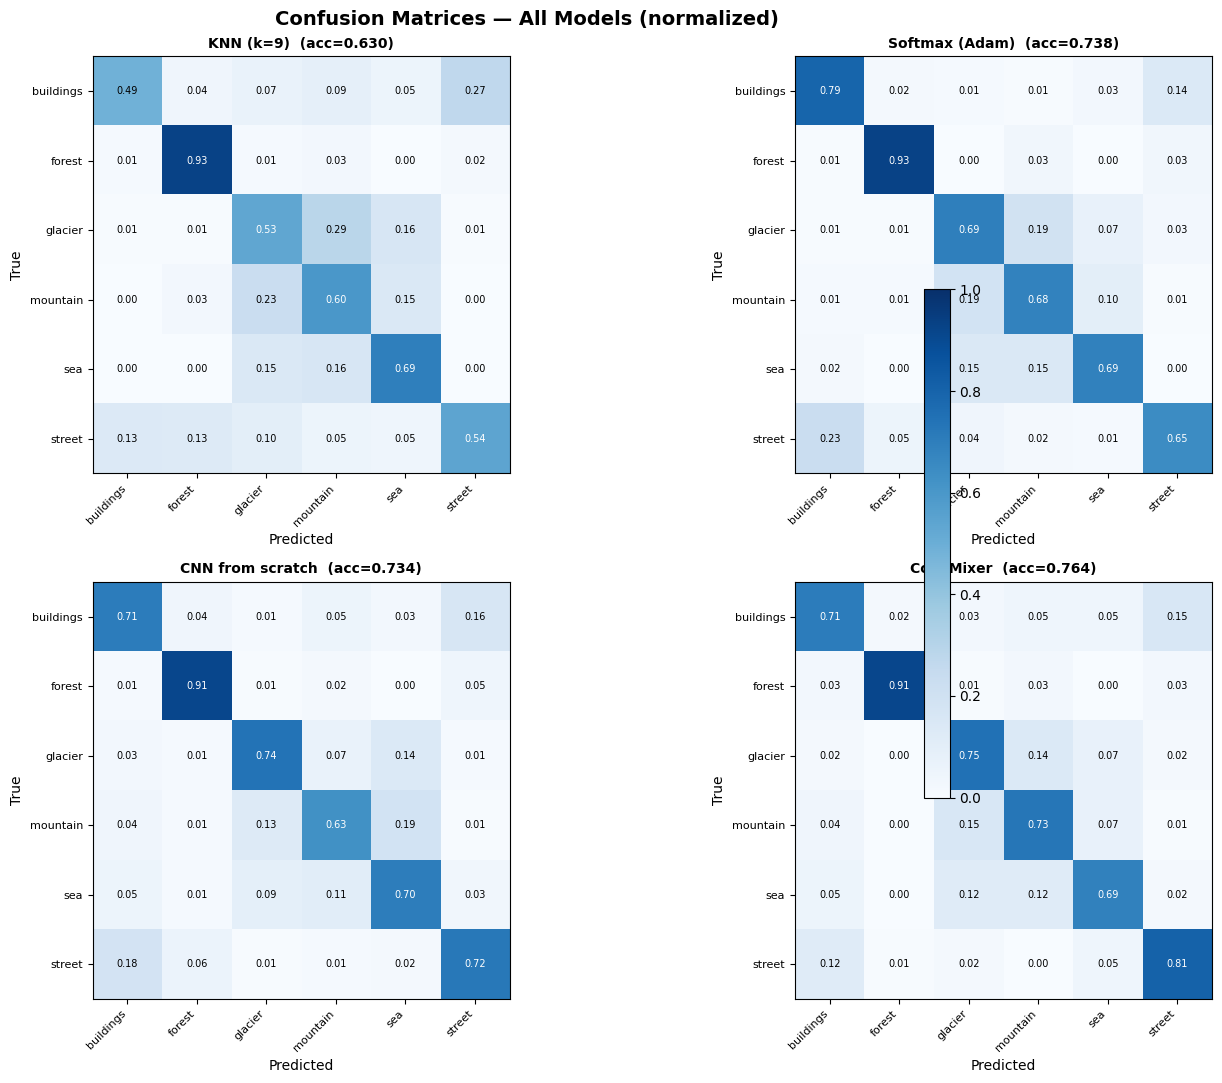

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Confusion Matrices — All Models (normalized)', fontsize=14, fontweight='bold')

for ax, (name, r) in zip(axes.ravel(), results.items()):
    cm   = r['confusion_matrix'].astype(np.float64)
    cm_n = cm / (cm.sum(axis=1, keepdims=True) + 1e-8)
    C    = len(CLASS_NAMES)

    im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(C))
    ax.set_yticks(range(C))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_title(f'{name}  (acc={r["accuracy"]:.3f})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

    thresh = 0.5
    for i in range(C):
        for j in range(C):
            ax.text(j, i, f'{cm_n[i,j]:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if cm_n[i,j] > thresh else 'black')

plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'confusion_matrices_all.png'), dpi=120, bbox_inches='tight')
plt.show()

## 5. Per-class F1 comparison

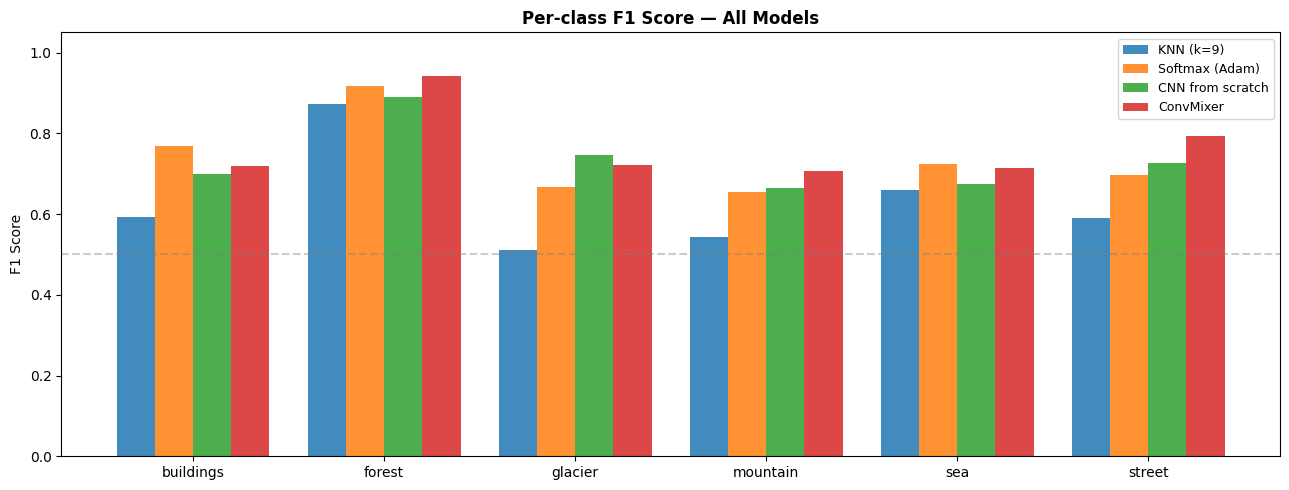

In [14]:
model_names = list(results.keys())
n_models    = len(model_names)
n_classes   = len(CLASS_NAMES)
x           = np.arange(n_classes)
width       = 0.2

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, r) in enumerate(results.items()):
    offset = (i - n_models/2 + 0.5) * width
    bars = ax.bar(x + offset, r['f1'], width, label=name, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=10)
ax.set_ylabel('F1 Score')
ax.set_title('Per-class F1 Score — All Models', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'f1_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()

## 6. Training curves — Softmax, CNN, ConvMixer

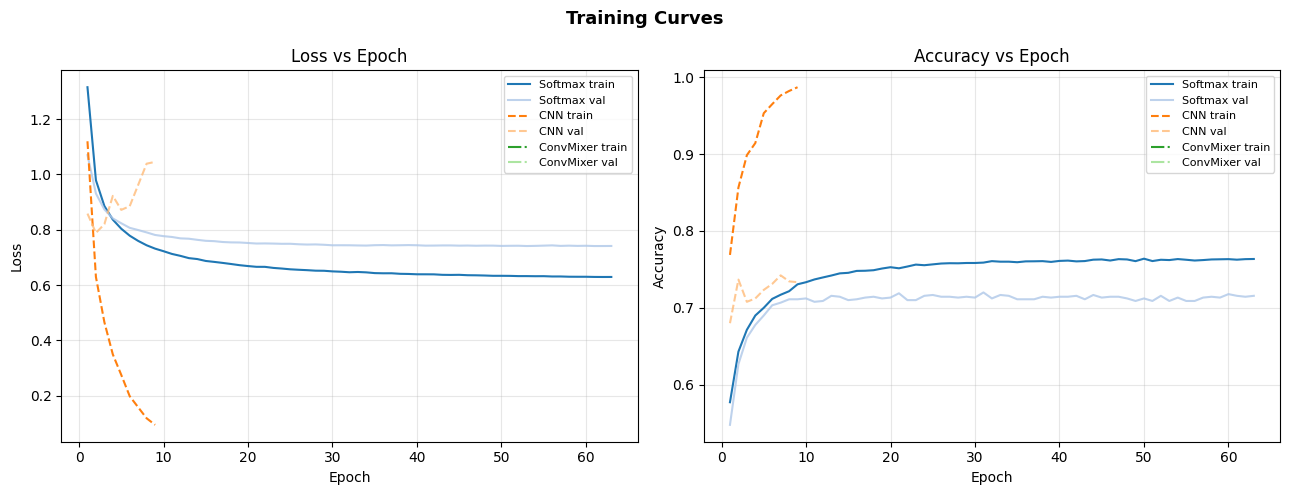

In [15]:
def load_log(pattern):
    files = sorted(glob.glob(os.path.join(LOGS_DIR, pattern)))
    if not files:
        return None
    rows = []
    with open(files[-1]) as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append({k: float(v) for k, v in row.items()})
    return rows

logs = {
    'Softmax':    load_log('softmax_adam_*_logs.csv'),
    'CNN':        load_log('cnn_adam_*_logs.csv'),
    'ConvMixer':  load_log('convmixer_*_logs.csv'),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Training Curves', fontsize=13, fontweight='bold')

line_styles = ['-', '--', '-.']
colors_train = ['#1f77b4', '#ff7f0e', '#2ca02c']
colors_val   = ['#aec7e8', '#ffbb78', '#98df8a']

for ax, metric, ylabel in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
    for i, (name, log) in enumerate(logs.items()):
        if log is None:
            continue
        epochs     = [r['epoch'] for r in log]
        train_vals = [r[f'train_{metric}'] for r in log]
        val_vals   = [r[f'val_{metric}'] for r in log]
        ax.plot(epochs, train_vals, color=colors_train[i],
                linestyle=line_styles[i], label=f'{name} train')
        ax.plot(epochs, val_vals, color=colors_val[i],
                linestyle=line_styles[i], label=f'{name} val', alpha=0.8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} vs Epoch')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

## 7. Final summary bar chart

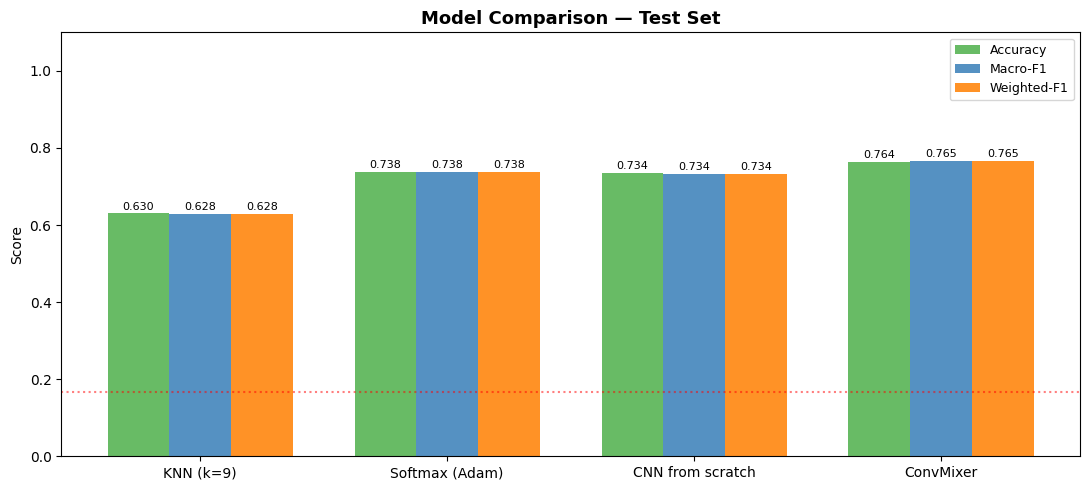

In [16]:
names   = list(results.keys())
accs    = [results[n]['accuracy']    for n in names]
mf1s    = [results[n]['macro_f1']    for n in names]
wf1s    = [results[n]['weighted_f1'] for n in names]

x     = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width, accs, width, label='Accuracy',     color='#4daf4a', alpha=0.85)
b2 = ax.bar(x,         mf1s, width, label='Macro-F1',     color='#377eb8', alpha=0.85)
b3 = ax.bar(x + width, wf1s, width, label='Weighted-F1',  color='#ff7f00', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(y=1/6, color='red', linestyle=':', alpha=0.5, label='Random chance')
plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'model_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()